<a href="https://colab.research.google.com/github/sindla97/Machine-Learning/blob/main/census_bureau_cust_seg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [164]:
import pandas as pd
import numpy as np

In [165]:
columns=pd.read_csv('/content/census-bureau.columns',sep=',',names=['columns'])
columns['columns']=columns['columns'].str.replace(' ','_')
columns

,columns
0,age
1,class_of_worker
2,detailed_industry_recode
3,detailed_occupation_recode
4,education
5,wage_per_hour
6,enroll_in_edu_inst_last_wk
7,marital_stat
8,major_industry_code
9,major_occupation_code


In [166]:
df=pd.read_csv('/content/census-bureau.data', sep=",",names=columns['columns'].tolist())
df.head()

,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,enroll_in_edu_inst_last_wk,marital_stat,major_industry_code,major_occupation_code,...,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veteran's_admin,veterans_benefits,weeks_worked_in_year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [167]:
#imputing with the most popular category
df['hispanic_origin']=np.where(df['hispanic_origin'].isna(),'All other', df['hispanic_origin'])

In [168]:
df['detailed_occupation_recode']=df['detailed_occupation_recode'].astype('object')
df['detailed_industry_recode']=df['detailed_industry_recode'].astype('object')
df['veterans_benefits']=df['veterans_benefits'].astype('int').astype('object')
df['own_business_or_self_employed']=df['own_business_or_self_employed'].astype('int').astype('object')


In [169]:
df['label']=df['label'].apply(lambda x: 1 if x=='50000+.' else 0)


In [170]:
import pandas as pd

education_map = {

    'Children': 'Low_ed',
    'Less than 1st grade': 'Low_ed',
    '1st 2nd 3rd or 4th grade': 'Low_ed',
    '5th or 6th grade': 'Low_ed',
    '7th and 8th grade': 'Low_ed',
    '9th grade': 'Low_ed',
    '10th grade': 'Low_ed',
    '11th grade': 'Low_ed',
    '12th grade no diploma': 'Low_ed',

    'High school graduate': 'HS-College',
    'Some college but no degree': 'HS-College',
    'Associates degree-academic program': 'HS-College',
    'Associates degree-occup /vocational': 'HS-College',
    'Bachelors degree(BA AB BS)': 'Professional',
    'Masters degree(MA MS MEng MEd MSW MBA)': 'Professional',

    'Doctorate degree(PhD EdD)': 'Professional',
    'Prof school degree (MD DDS DVM LLB JD)': 'Professional'
}

df['education'] = df['education'].map(education_map)


In [171]:
# dropping "state_of_previous_residence" as we already have 'region_of_previous_residence'
# dropping 'country_of_birth_father' & 'country_of_birth_mother' because of high cardinality and high associate with 'country_of_birth_self'
# dropping 'detailed_industry_recode', 'detailed_occupation_recode becuase we have 'detailed_industry_recode', 'detailed_occupation_recode'
df.drop(columns=['state_of_previous_residence','country_of_birth_father','country_of_birth_mother','detailed_industry_recode','detailed_occupation_recode'],axis=1, inplace=True)

In [172]:
unique_cnt=[]
data_type_df=df.dtypes.reset_index(name='data_type')
data_type_df

for i in data_type_df['index'].tolist():
  #print(data_type_df.loc[data_type_df['index']==i,'data_type'])
  if data_type_df.loc[data_type_df['index'] == i, 'data_type'].iloc[0] == 'object':
    unique_cnt.append(df[i].nunique())
  else: unique_cnt.append(0)
#print(unique_cnt)
data_type_df['nunique']=pd.Series(unique_cnt)
data_type_df

# df['class_of_worker'].unique().tolist()

,index,data_type,nunique
0,age,int64,0
1,class_of_worker,object,9
2,education,object,3
3,wage_per_hour,int64,0
4,enroll_in_edu_inst_last_wk,object,3
5,marital_stat,object,7
6,major_industry_code,object,24
7,major_occupation_code,object,15
8,race,object,5
9,hispanic_origin,object,9


(array([10.,  8.,  4.,  3.,  3.,  5.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  1.]),
 array([ 0.  ,  1.72,  3.44,  5.16,  6.88,  8.6 , 10.32, 12.04, 13.76,
        15.48, 17.2 , 18.92, 20.64, 22.36, 24.08, 25.8 , 27.52, 29.24,
        30.96, 32.68, 34.4 , 36.12, 37.84, 39.56, 41.28, 43.  ]),
 <BarContainer object of 25 artists>)

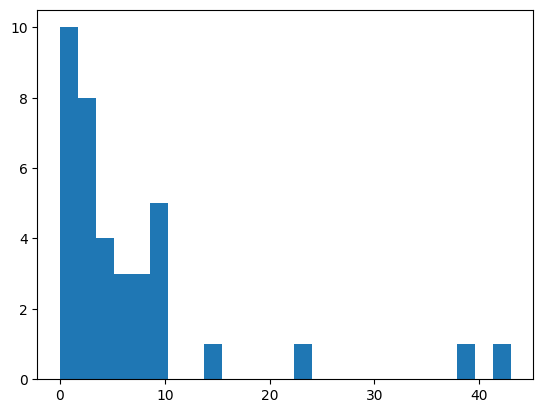

In [173]:
import matplotlib.pyplot as plt
plt.hist(data_type_df['nunique'], bins=25)

In [174]:
df['detailed_household_summary_in_household'].value_counts()

,count
detailed_household_summary_in_household,
Householder,75475
Child under 18 never married,50426
Spouse of householder,41709
Child 18 or older,14430
Other relative of householder,9703
Nonrelative of householder,7601
Group Quarters- Secondary individual,132
Child under 18 ever married,47


In [175]:
# states_df=df.groupby(['state_of_previous_residence'])['label'].mean().reset_index(name='mt').sort_values(by='mt',ascending=False)
# states_df['value']=states_df['mt'].apply(lambda x: 'High_value' if x>0.07 else 'Med_value' if x>0.03 and x<=0.07 else 'Low_val')
# states_dict={}
# for i in states_df['state_of_previous_residence'].tolist():
#   states_dict[i]=states_df.loc[states_df['state_of_previous_residence']==i,'value'].iloc[0]
# states_dict

In [176]:
target='label'
sample_weight='weight'
cat_l_cardinal_col= [x for x in data_type_df.loc[(data_type_df['data_type']=='object') &(data_type_df['nunique']<=4),'index'].tolist() if x not in [target,sample_weight]]
cat_h_cardinal_col= [x for x in data_type_df.loc[data_type_df['data_type']=='object','index'].tolist() if x not in [target,sample_weight]+cat_l_cardinal_col]
int_columns= [x for x in data_type_df.loc[data_type_df['data_type']=='int64','index'].tolist() if x not in [target,sample_weight]]
print(len(cat_l_cardinal_col), len(cat_h_cardinal_col), len(int_columns))

9 18 8


In [177]:
df.replace({'?': 'unknown'}, inplace=True)


In [178]:
cat_feat_exp = pd.DataFrame()

for i in cat_h_cardinal_col:
  v_counts=df[i].value_counts().reset_index(name='value_counts').rename(columns={f'{i}':'values'})
  v_counts['value_counts_percent']=(v_counts['value_counts']/df.shape[0])*100

  v_counts['feature']=i
  cat_feat_exp=pd.concat([cat_feat_exp,v_counts], axis=0,ignore_index=True)
cat_feat_exp=cat_feat_exp.merge(data_type_df, left_on='feature', right_on='index')
cat_feat_exp


,values,value_counts,value_counts_percent,feature,index,data_type,nunique
0,Not in universe,100245,50.242328,class_of_worker,class_of_worker,object,9
1,Private,72028,36.100099,class_of_worker,class_of_worker,object,9
2,Self-employed-not incorporated,8445,4.232595,class_of_worker,class_of_worker,object,9
3,Local government,7784,3.901305,class_of_worker,class_of_worker,object,9
4,State government,4227,2.118553,class_of_worker,class_of_worker,object,9
...,...,...,...,...,...,...,...
218,Native- Born in the United States,176992,88.707568,citizenship,citizenship,object,5
219,Foreign born- Not a citizen of U S,13401,6.716519,citizenship,citizenship,object,5
220,Foreign born- U S citizen by naturalization,5855,2.934499,citizenship,citizenship,object,5
221,Native- Born abroad of American Parent(s),1756,0.880099,citizenship,citizenship,object,5


In [179]:
hcard_converge=cat_feat_exp[((cat_feat_exp['value_counts_percent']<=5)&(cat_feat_exp['nunique']<=10)) |((cat_feat_exp['value_counts_percent']<=3) &(cat_feat_exp['nunique']>=10))]



In [180]:
for i in cat_h_cardinal_col:
  comp_cat = hcard_converge.loc[hcard_converge['feature'] == i, 'values'].tolist()

  df[i] = df[i].where(~df[i].isin(comp_cat), 'other')
  # print(df[i].value_counts())

In [181]:
for i in int_columns:
  if i in ['wage_per_hour','capital_gains','capital_losses','dividends_from_stocks']:
    df[i]=np.where(df[i]==0,0, np.log1p(df[i]))


In [182]:
import warnings
warnings.filterwarnings('ignore')

In [183]:
global_mean = df[target].mean()

for feature in cat_h_cardinal_col:

  pop_map = df[feature].value_counts()/df.shape[0]
  df[f'{feature}_enc_pop'] = df[feature].map(pop_map)
  df[f'{feature}_enc_pop'].fillna(global_mean, inplace=True)

## Kmean(with scaled fetaures)
may be use PCA to cutdown on dimentionality and apply K Means


In [184]:
cat_l_cardinal_col_encoded=[]
# df['label']=df['label'].astype('category')

from sklearn.preprocessing import OneHotEncoder
for i in cat_l_cardinal_col:

  oe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


  encoded = oe.fit_transform(df[[i]])

  encoded_cols = oe.get_feature_names_out([i])

  train_encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=df.index)

  df = pd.concat([df, train_encoded_df], axis=1)
  cat_l_cardinal_col_encoded.extend(encoded_cols)


In [185]:
final_features_kmeans=[x for x in int_columns if x not in ['year']]+cat_l_cardinal_col_encoded+[f'{x}_enc_pop' for x in cat_h_cardinal_col]
final_features_kmeans

['age',
 'wage_per_hour',
 'capital_gains',
 'capital_losses',
 'dividends_from_stocks',
 'num_persons_worked_for_employer',
 'weeks_worked_in_year',
 'education_HS-College',
 'education_Low_ed',
 'education_Professional',
 'enroll_in_edu_inst_last_wk_College or university',
 'enroll_in_edu_inst_last_wk_High school',
 'enroll_in_edu_inst_last_wk_Not in universe',
 'sex_Female',
 'sex_Male',
 'member_of_a_labor_union_No',
 'member_of_a_labor_union_Not in universe',
 'member_of_a_labor_union_Yes',
 'live_in_this_house_1_year_ago_No',
 'live_in_this_house_1_year_ago_Not in universe under 1 year old',
 'live_in_this_house_1_year_ago_Yes',
 'migration_prev_res_in_sunbelt_No',
 'migration_prev_res_in_sunbelt_Not in universe',
 'migration_prev_res_in_sunbelt_Yes',
 'migration_prev_res_in_sunbelt_unknown',
 'own_business_or_self_employed_0',
 'own_business_or_self_employed_1',
 'own_business_or_self_employed_2',
 "fill_inc_questionnaire_for_veteran's_admin_No",
 "fill_inc_questionnaire_for_vet

In [186]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
df_scaled=ss.fit_transform(df[[x for x in final_features_kmeans if x not in cat_l_cardinal_col_encoded]])

df_scaled=np.concatenate((df_scaled, df[cat_l_cardinal_col_encoded].to_numpy()), axis=1)

df_scaled
# pd.conact([df,df_scaled],axis=1)

array([[ 1.72587866, -0.24430994, -0.19446972, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.05355971, -0.24430994, -0.19446972, ...,  0.        ,
         0.        ,  1.        ],
       [-0.73929082, -0.24430994, -0.19446972, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.56052581, -0.24430994, -0.19446972, ...,  0.        ,
         0.        ,  1.        ],
       [-0.82893335, -0.24430994, -0.19446972, ...,  0.        ,
         0.        ,  1.        ],
       [-0.11179313, -0.24430994, -0.19446972, ...,  0.        ,
         0.        ,  1.        ]])

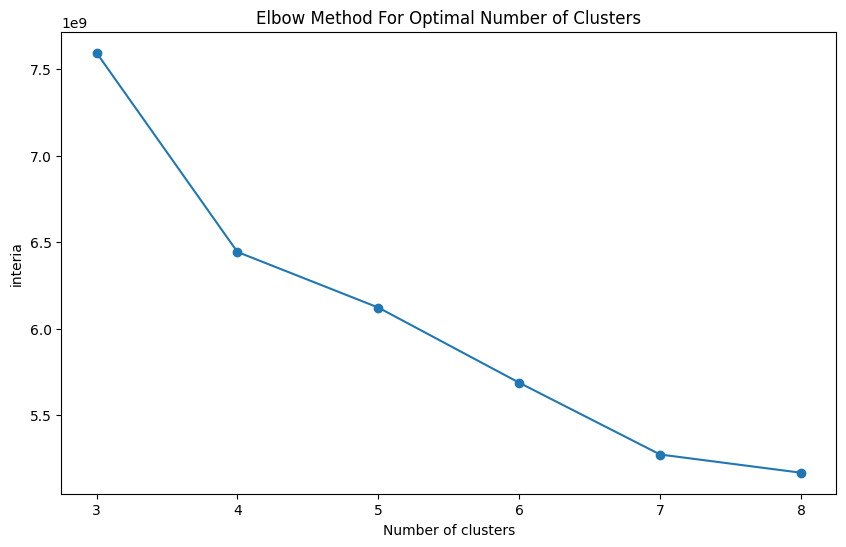

In [187]:
from sklearn.cluster import KMeans

interia = []
for i in range(3,9):
  km=KMeans(n_clusters=i,random_state=42, n_init='auto')
  clusters_weighted = km.fit_predict(df_scaled, sample_weight=df[sample_weight])
  interia.append(km.inertia_)

# Plot the elbow graph
plt.figure(figsize=(10, 6))
plt.plot(range(3, 9), interia, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('interia')
plt.show()


In [188]:
# from sklearn.metrics import silhouette_score

# scores = []
# for k in range(3, 10):
#     km = KMeans(n_clusters=k, random_state=42)
#     labels = km.fit_predict(df_scaled, sample_weight=df[sample_weight])
#     scores.append(silhouette_score(df_scaled, labels))

# plt.plot(range(3, 10), scores, 'o-')
# plt.xlabel('Number of clusters')
# plt.ylabel('Silhouette Score')
# plt.show()

#using PCA to cutdown on dimentionality and apply K Means

In [189]:
#one hot encoding does not make sense when using PCA
global_mean = df[target].mean()

for feature in cat_l_cardinal_col:

  pop_map = df[feature].value_counts()/df.shape[0]
  df[f'{feature}_enc_pop'] = df[feature].map(pop_map)
  df[f'{feature}_enc_pop'].fillna(global_mean, inplace=True)

In [190]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
df_scaled=ss.fit_transform(df[[x for x in final_features_kmeans if x not in cat_l_cardinal_col_encoded]+[f'{x}_enc_pop' for x in cat_l_cardinal_col]])
df_scaled

array([[ 1.72587866, -0.24430994, -0.19446972, ...,  0.32287147,
         0.10021739,  0.57083228],
       [ 1.05355971, -0.24430994, -0.19446972, ...,  0.32287147,
         0.10021739,  0.57083228],
       [-0.73929082, -0.24430994, -0.19446972, ...,  0.32287147,
         0.10021739,  0.57083228],
       ...,
       [ 0.56052581, -0.24430994, -0.19446972, ...,  0.32287147,
         0.10021739,  0.57083228],
       [-0.82893335, -0.24430994, -0.19446972, ...,  0.32287147,
         0.10021739,  0.57083228],
       [-0.11179313, -0.24430994, -0.19446972, ...,  0.32287147,
         0.10021739,  0.57083228]])

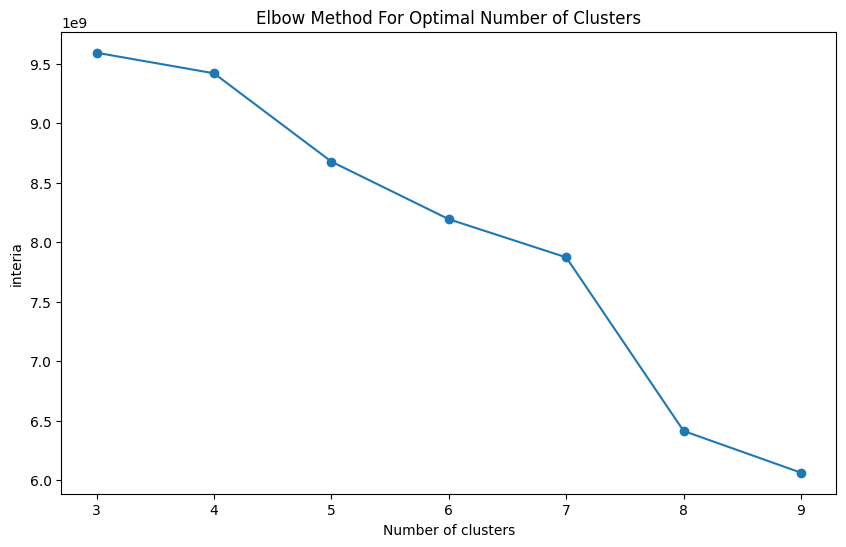

In [195]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
pca = PCA(n_components=0.9)
df_scaled_pca=pca.fit_transform(df_scaled)
interia = []
for k in range(3, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df_scaled, sample_weight=df[sample_weight])
    interia.append(km.inertia_)

# Plot the elbow graph
plt.figure(figsize=(10, 6))
plt.plot(range(3, 10), interia, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('interia')
plt.show()